In [3]:
import pandas as pd
print(pd.__version__)
import matplotlib.pyplot as plt

URL = (
    "https://raw.githubusercontent.com/"
    "cfneves/turma-visualizacao-de-dados/"
    "master/datasets/base_rh.csv"
)

df = pd.read_csv(URL, 
    sep=";", 
    encoding="cp1252", 
    decimal=","
    )

df["Data_Admissao"] = pd.to_datetime(
    df["Data_Admissao"],
    format="%d/%m/%Y",
    errors="coerce"   # datas inválidas → NaT (não quebra o pipeline)
)

print(f"Dataset carregado: {df.shape[0]} linhas x, {df.shape[1]} colunas")

3.0.2
Dataset carregado: 1000 linhas x, 10 colunas


# Histograma: como os salários estão distribuídos


Um **histograma** divide os valores em faixas e mostra quantos registros caem em cada faixa. É o gráfico ideal para entender a **distribuição** de uma variável numérica.

- **Eixo X** → faixas de salário
- **Eixo Y** → quantidade de funcionários naquela faixa
- `bins=10` → divide o intervalo total em 10 faixas iguais

O padrão de construção de qualquer gráfico com matplotlib é sempre este:

```python
plt.hist(...)       # 1. cria o gráfico
plt.title(...)      # 2. adiciona título
plt.xlabel(...)     # 3. rótulo do eixo X
plt.ylabel(...)     # 4. rótulo do eixo Y
plt.show()          # 5. exibe na tela
```

Memorize esse padrão — ele vai se repetir em todos os gráficos.

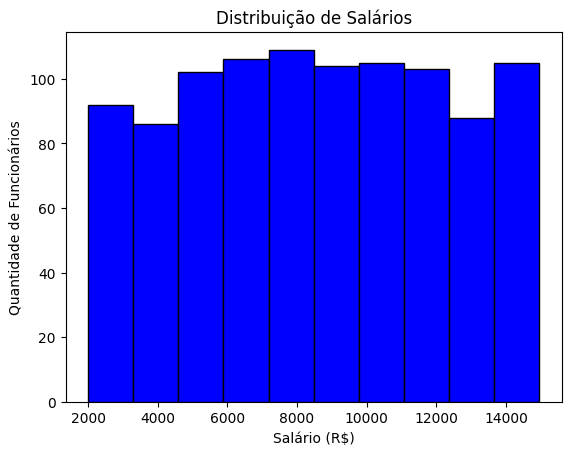

In [9]:
# Histograma mostra como os salários estão distribuídos
# bins=10 divide o intervalo em 10 faixas iguais
plt.hist(df["Salario"], bins=10, color="b", edgecolor="black")
plt.title("Distribuição de Salários")
plt.xlabel("Salário (R$)")
plt.ylabel("Quantidade de Funcionários")
plt.show()

---
### O que este gráfico mostra?

Cada barra representa uma **faixa de salário** e sua altura indica **quantos funcionários** ganham dentro daquela faixa. O eixo X vai do menor ao maior salário; o eixo Y mostra a frequência (quantidade).

### Por que isso importa?

A distribuição salarial revela a **estrutura de remuneração** da empresa:

- Se as barras formam um "pico" no centro → a maioria ganha salários próximos (distribuição equilibrada)
- Se o pico está à esquerda e a cauda se estende para a direita → poucos funcionários ganham muito mais que a maioria (assimetria positiva)
- Picos muito estreitos podem indicar pouca variação salarial — o que pode significar falta de progressão de carreira

> Lembre-se: compare sempre a **média** com a **mediana** para entender se os altos salários estão distorcendo a percepção do salário típico.

## Célula 8 — Índices: o "endereço" de cada linha

Por padrão, o pandas numera cada linha: 0, 1, 2, 3... Esse número é o **índice** — pense nele como o número de um apartamento, um endereço único.

Com `set_index("ID_Funcionario")`, fazemos a coluna `ID_Funcionario` virar o novo índice. A partir daí, usamos `df_idx.loc[3]` para acessar diretamente o funcionário de ID 3 — muito mais intuitivo!

`reset_index()` desfaz isso e volta ao índice numérico padrão.

**Detalhe importante:** quando filtramos o DataFrame (`df[df["Status"] == "Ativo"]`), o índice **não é reiniciado**. Os números originais são mantidos — por isso o primeiro índice dos ativos pode ser 1, 2, 5... e não necessariamente 0.

In [14]:
# Índice padrão
print("Índice padrão:", df.index)

# set_index: ID_Funcionario vira o endereço
df_idx = df.set_index("ID_Funcionario")
print("\nFuncionário ID=3:")
print(df_idx.loc[3][["Nome", "Departamento", "Salario"]])

# reset_index: volta ao numérico
df_volta = df_idx.reset_index()
print(f"\nColunas após reset_index: {df_volta.columns.tolist()}")

# Índice após filtro — não começa em 0!
ativos = df[df["Status"] == "Ativo"]
print(f"\nPrimeiro índice dos Ativos : {ativos.index[0]}")
print(f"Total de Ativos            : {len(ativos)}")
inativos = df[df["Status"] == "Inativo"]
print(f"Total de Inativos          : {len(inativos)}")

Índice padrão: RangeIndex(start=0, stop=1000, step=1)

Funcionário ID=3:
Nome            Srta. Mariana Cunha
Departamento                     RH
Salario                    14027.93
Name: 3, dtype: object

Colunas após reset_index: ['ID_Funcionario', 'Nome', 'Departamento', 'Cargo', 'Salario', 'Data_Admissao', 'Genero', 'Idade', 'Estado_Civil', 'Status']

Primeiro índice dos Ativos : 2
Total de Ativos            : 515
Total de Inativos          : 485


## Célula 9 — Gráfico de barras: comparando categorias

O **gráfico de barras** é ideal para comparar quantidades entre categorias diferentes. Aqui queremos ver quantos funcionários são "Ativo" e quantos são "Inativo".

Seguimos o padrão: **calcular primeiro, plotar depois**.

1. `df["Status"].value_counts()` → conta quantas vezes cada valor aparece
2. `plt.bar(contagem.index, contagem.values)` → `index` = rótulos (x), `values` = quantidades (altura das barras)

Passamos uma lista de cores para diferenciar visualmente as categorias.

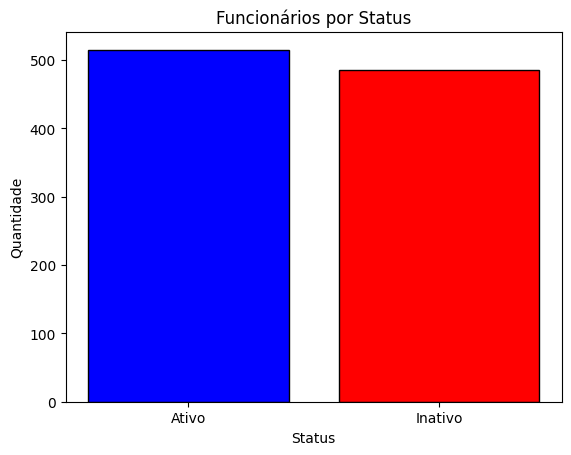

In [18]:
# Calculamos o que queremos mostrar
contagem = df["Status"].value_counts()

# Gráfico de barras: x = rótulos, height = valores
plt.bar(contagem.index, contagem.values, color=["b", "r"], edgecolor="black")
plt.title("Funcionários por Status")
plt.xlabel("Status")
plt.ylabel("Quantidade")
plt.show()